In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models.segmentation import deeplabv3_resnet50
import numpy as np
import cv2
from PIL import Image
import os
import matplotlib.pyplot as plt
from sklearn.metrics import jaccard_score
import pandas as pd
from tqdm import tqdm

In [ ]:
class Config:
    # Paths
    IMAGES_PATH = "/content/drive/MyDrive/Images"
    MASKS_PATH = "/content/drive/MyDrive/mask"

    # Model parameters
    NUM_CLASSES = 2  #  based on your segmentation classes
    INPUT_SIZE = (256, 256)
    BATCH_SIZE = 8
    LEARNING_RATE = 0.001
    NUM_EPOCHS = 50
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

config = Config()

In [ ]:
class SegmentationDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None, mask_transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform
        self.mask_transform = mask_transform

        # Get all image files
        self.image_files = sorted([f for f in os.listdir(images_dir)
                                 if f.endswith(('.png', '.jpg', '.jpeg'))])
        self.mask_files = sorted([f for f in os.listdir(masks_dir)
                                if f.endswith(('.png', '.jpg', '.jpeg'))])

        print(f"Found {len(self.image_files)} images and {len(self.mask_files)} masks")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Load image
        img_path = os.path.join(self.images_dir, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')

        # Load mask
        mask_path = os.path.join(self.masks_dir, self.mask_files[idx])
        mask = Image.open(mask_path).convert('L')  # Convert to grayscale

        # Resize
        image = image.resize(config.INPUT_SIZE, Image.BILINEAR)
        mask = mask.resize(config.INPUT_SIZE, Image.NEAREST)

        # Convert to numpy arrays
        image = np.array(image)
        mask = np.array(mask)

        # Normalize mask to 0-1 if it's not binary
        if mask.max() > 1:
            mask = mask / 255.0

        # Convert to tensors
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(mask).long()

        # Ensure mask has proper class values (0 for background, 1 for foreground)
        if mask.max() > 1:
            mask = (mask > 0).long()

        return image, mask

In [ ]:
def create_deeplabv3_model(num_classes):
    """Create DeepLabV3 model with ResNet50 backbone"""
    model = deeplabv3_resnet50(pretrained=True, progress=True)

    # Modify the classifier for the number of classes
    model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=(1, 1), stride=(1, 1))
    model.aux_classifier[4] = nn.Conv2d(256, num_classes, kernel_size=(1, 1), stride=(1, 1))

    return model

def initialize_model():
    """Initialize model, criterion, and optimizer"""
    model = create_deeplabv3_model(config.NUM_CLASSES)
    model = model.to(config.DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

    return model, criterion, optimizer

In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, masks in tqdm(dataloader, desc="Training"):
        images = images.to(device)
        masks = masks.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs['out'], masks)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(dataloader)

def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    iou_scores = []

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Validation"):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs['out'], masks)
            running_loss += loss.item()

            # Calculate IoU
            preds = torch.argmax(outputs['out'], dim=1)
            iou = calculate_iou(preds, masks)
            iou_scores.append(iou)

    return running_loss / len(dataloader), np.mean(iou_scores)

def calculate_iou(preds, targets):
    """Calculate Intersection over Union"""
    preds = preds.cpu().numpy().flatten()
    targets = targets.cpu().numpy().flatten()

    # Handle case where there might be no foreground in both pred and target
    if (preds.sum() == 0) and (targets.sum() == 0):
        return 1.0

    return jaccard_score(targets, preds, average='binary')

In [ ]:
import time
from datetime import datetime

def train_epoch(model, dataloader, criterion, optimizer, device, epoch):
    model.train()
    running_loss = 0.0
    batch_time = AverageMeter()
    data_time = AverageMeter()
    losses = AverageMeter()

    end = time.time()

    progress_bar = tqdm(enumerate(dataloader), total=len(dataloader),
                       desc=f'Epoch {epoch+1} [Train]')

    for batch_idx, (images, masks) in progress_bar:
        # Measure data loading time
        data_time.update(time.time() - end)

        images = images.to(device)
        masks = masks.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs['out'], masks)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update metrics
        losses.update(loss.item(), images.size(0))
        batch_time.update(time.time() - end)
        end = time.time()

        # Update progress bar
        progress_bar.set_postfix({
            'Loss': f'{losses.avg:.4f}',
            'Batch Time': f'{batch_time.avg:.3f}s',
            'Data Time': f'{data_time.avg:.3f}s'
        })

    return losses.avg

def validate_epoch(model, dataloader, criterion, device, epoch):
    model.eval()
    losses = AverageMeter()
    iou_scores = AverageMeter()

    progress_bar = tqdm(enumerate(dataloader), total=len(dataloader),
                       desc=f'Epoch {epoch+1} [Val]')

    with torch.no_grad():
        for batch_idx, (images, masks) in progress_bar:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs['out'], masks)

            # Calculate IoU
            preds = torch.argmax(outputs['out'], dim=1)
            iou = calculate_iou(preds, masks)

            # Update metrics
            losses.update(loss.item(), images.size(0))
            iou_scores.update(iou, images.size(0))

            # Update progress bar
            progress_bar.set_postfix({
                'Loss': f'{losses.avg:.4f}',
                'IoU': f'{iou_scores.avg:.4f}'
            })

    return losses.avg, iou_scores.avg

class AverageMeter:
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [ ]:
def main():
    print(" Initializing Segmentation Training...")
    print("=" * 60)

    # Create datasets
    print("📁 Loading datasets...")
    full_dataset = SegmentationDataset(config.IMAGES_PATH, config.MASKS_PATH)

    # Split dataset
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(
        full_dataset, [train_size, val_size]
    )

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE,
                            shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

    # Initialize model
    print(" Initializing DeepLabV3 model...")
    model, criterion, optimizer = initialize_model()

    # Print model summary
    total_params = sum(p.numel() for p in model.parameters())
    print(f" Model Parameters: {total_params:,}")
    print(f"  Training on: {config.DEVICE}")
    print(f" Training samples: {len(train_dataset):,}")
    print(f" Validation samples: {len(val_dataset):,}")
    print(f" Number of classes: {config.NUM_CLASSES}")
    print("=" * 60)

    # Training history
    history = {
        'epoch': [],
        'train_loss': [],
        'val_loss': [],
        'val_iou': [],
        'learning_rate': []
    }

    best_iou = 0.0
    start_time = time.time()

    print(" Starting training...")
    for epoch in range(config.NUM_EPOCHS):
        epoch_start = time.time()

        print(f"\n Epoch {epoch+1}/{config.NUM_EPOCHS}")
        print("-" * 50)

        # Train
        train_loss = train_epoch(model, train_loader, criterion, optimizer, config.DEVICE, epoch)

        # Validate
        val_loss, val_iou = validate_epoch(model, val_loader, criterion, config.DEVICE, epoch)

        epoch_time = time.time() - epoch_start

        # Update history
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_iou'].append(val_iou)
        history['learning_rate'].append(optimizer.param_groups[0]['lr'])

        # Print epoch summary
        print(f" Epoch {epoch+1} Summary:")
        print(f"   ├── Train Loss:    {train_loss:.4f}")
        print(f"   ├── Val Loss:      {val_loss:.4f}")
        print(f"   ├── Val IoU:       {val_iou:.4f}")
        print(f"   ├── Epoch Time:    {epoch_time:.2f}s")
        print(f"   └── Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")

        # Save best model
        if val_iou > best_iou:
            best_iou = val_iou
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_iou': val_iou,
                'val_loss': val_loss,
                'train_loss': train_loss,
                'history': history,
            }, 'best_deeplabv3_model.pth')
            print(f" NEW BEST MODEL SAVED! IoU: {val_iou:.4f}")

        # Save checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0:
            checkpoint_path = f'checkpoint_epoch_{epoch+1}.pth'
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_iou': val_iou,
                'history': history,
            }, checkpoint_path)
            print(f" Checkpoint saved: {checkpoint_path}")

    total_time = time.time() - start_time
    print(f"\nTraining completed in {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
    print(f" Best Validation IoU: {best_iou:.4f}")

    return model, history

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models.segmentation import deeplabv3_resnet50
import numpy as np
import cv2
from PIL import Image
import os
import matplotlib.pyplot as plt
from sklearn.metrics import jaccard_score
import pandas as pd
from tqdm import tqdm
import time
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

print(" Libraries imported successfully!")
print(" Google Drive mounted!")

Mounted at /content/drive
 Libraries imported successfully!
 Google Drive mounted!


In [ ]:
class Config:
    # Update these paths to match your actual folder structure
    IMAGES_PATH = "/content/drive/MyDrive/Images"  # Update if needed
    MASKS_PATH = "/content/drive/MyDrive/mask"     # Update if needed

    # Model parameters
    NUM_CLASSES = 2
    INPUT_SIZE = (256, 256)
    BATCH_SIZE = 4  # Reduced for testing
    LEARNING_RATE = 0.001
    NUM_EPOCHS = 5   # Reduced for testing
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

config = Config()

print(f" Image path: {config.IMAGES_PATH}")
print(f" Mask path: {config.MASKS_PATH}")
print(f"  Device: {config.DEVICE}")

# Check if paths exist
print(f" Images folder exists: {os.path.exists(config.IMAGES_PATH)}")
print(f" Masks folder exists: {os.path.exists(config.MASKS_PATH)}")

# List files in directories
if os.path.exists(config.IMAGES_PATH):
    image_files = os.listdir(config.IMAGES_PATH)
    print(f" Found {len(image_files)} images: {image_files[:5]}...")  # Show first 5

if os.path.exists(config.MASKS_PATH):
    mask_files = os.listdir(config.MASKS_PATH)
    print(f" Found {len(mask_files)} masks: {mask_files[:5]}...")  # Show first 5

 Image path: /content/drive/MyDrive/Images
 Mask path: /content/drive/MyDrive/mask
  Device: cpu
 Images folder exists: True
 Masks folder exists: True
 Found 500 images: ['500.jpg', '493.jpg', '499.jpg', '488.jpg', '497.jpg']...
 Found 500 masks: ['430.jpg', '405.jpg', '421.jpg', '438.jpg', '427.jpg']...


In [ ]:
class SegmentationDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None, mask_transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform
        self.mask_transform = mask_transform

        # Get all image files
        self.image_files = sorted([f for f in os.listdir(images_dir)
                                 if f.endswith(('.png', '.jpg', '.jpeg'))])
        self.mask_files = sorted([f for f in os.listdir(masks_dir)
                                if f.endswith(('.png', '.jpg', '.jpeg'))])

        print(f" Dataset initialized with {len(self.image_files)} images and {len(self.mask_files)} masks")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Load image
        img_path = os.path.join(self.images_dir, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')

        # Load mask
        mask_path = os.path.join(self.masks_dir, self.mask_files[idx])
        mask = Image.open(mask_path).convert('L')  # Convert to grayscale

        # Resize
        image = image.resize(config.INPUT_SIZE, Image.BILINEAR)
        mask = mask.resize(config.INPUT_SIZE, Image.NEAREST)

        # Convert to numpy arrays
        image = np.array(image)
        mask = np.array(mask)

        # Normalize mask to 0-1 if it's not binary
        if mask.max() > 1:
            mask = mask / 255.0

        # Convert to tensors
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(mask).long()


        if mask.max() > 1:
            mask = (mask > 0).long()

        return image, mask

# Test the dataset
try:
    test_dataset = SegmentationDataset(config.IMAGES_PATH, config.MASKS_PATH)
    print("Dataset created successfully!")

    # Test one sample
    if len(test_dataset) > 0:
        image, mask = test_dataset[0]
        print(f" Image shape: {image.shape}")
        print(f" Mask shape: {mask.shape}")
        print(f" Mask unique values: {torch.unique(mask)}")
    else:
        print(" No images found in dataset!")

except Exception as e:
    print(f" Error creating dataset: {e}")

 Dataset initialized with 500 images and 500 masks
Dataset created successfully!
 Image shape: torch.Size([3, 256, 256])
 Mask shape: torch.Size([256, 256])
 Mask unique values: tensor([0, 1])


In [ ]:
# Utility class
class AverageMeter:
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

# Model creation
def create_deeplabv3_model(num_classes):
    """Create DeepLabV3 model with ResNet50 backbone"""
    model = deeplabv3_resnet50(pretrained=True, progress=True)

    # Modify the classifier for the number of classes
    model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=(1, 1), stride=(1, 1))
    model.aux_classifier[4] = nn.Conv2d(256, num_classes, kernel_size=(1, 1), stride=(1, 1))

    return model

def initialize_model():
    """Initialize model, criterion, and optimizer"""
    model = create_deeplabv3_model(config.NUM_CLASSES)
    model = model.to(config.DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

    print(f" Model initialized with {sum(p.numel() for p in model.parameters()):,} parameters")
    return model, criterion, optimizer

# Metrics
def calculate_iou(preds, targets):
    """Calculate Intersection over Union"""
    preds = preds.cpu().numpy().flatten()
    targets = targets.cpu().numpy().flatten()

    # Handle case where there might be no foreground in both pred and target
    if (preds.sum() == 0) and (targets.sum() == 0):
        return 1.0

    return jaccard_score(targets, preds, average='binary')

print(" Model utilities defined!")

 Model utilities defined!


In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, device, epoch):
    model.train()
    running_loss = 0.0
    batch_time = AverageMeter()
    data_time = AverageMeter()
    losses = AverageMeter()

    end = time.time()

    progress_bar = tqdm(enumerate(dataloader), total=len(dataloader),
                       desc=f'Epoch {epoch+1} [Train]')

    for batch_idx, (images, masks) in progress_bar:
        # Measure data loading time
        data_time.update(time.time() - end)

        images = images.to(device)
        masks = masks.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs['out'], masks)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update metrics
        losses.update(loss.item(), images.size(0))
        batch_time.update(time.time() - end)
        end = time.time()

        # Update progress bar
        progress_bar.set_postfix({
            'Loss': f'{losses.avg:.4f}',
            'Batch Time': f'{batch_time.avg:.3f}s',
            'Data Time': f'{data_time.avg:.3f}s'
        })

    return losses.avg

def validate_epoch(model, dataloader, criterion, device, epoch):
    model.eval()
    losses = AverageMeter()
    iou_scores = AverageMeter()

    progress_bar = tqdm(enumerate(dataloader), total=len(dataloader),
                       desc=f'Epoch {epoch+1} [Val]')

    with torch.no_grad():
        for batch_idx, (images, masks) in progress_bar:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs['out'], masks)

            # Calculate IoU
            preds = torch.argmax(outputs['out'], dim=1)
            iou = calculate_iou(preds, masks)

            # Update metrics
            losses.update(loss.item(), images.size(0))
            iou_scores.update(iou, images.size(0))

            # Update progress bar
            progress_bar.set_postfix({
                'Loss': f'{losses.avg:.4f}',
                'IoU': f'{iou_scores.avg:.4f}'
            })

    return losses.avg, iou_scores.avg

print("Training functions defined!")

Training functions defined!


 STARTING TRAINING 
 Dataset initialized with 500 images and 500 masks
 Training samples: 400
 Validation samples: 100
 Model initialized with 41,994,308 parameters

 Epoch 1/5
-------------------------


Epoch 1 [Val]: 100%|██████████| 25/25 [03:07<00:00,  7.51s/it, Loss=0.1231, IoU=0.6362]


Epoch 1 Summary:
   ├── Train Loss:    0.1672
   ├── Val Loss:      0.1231
   ├── Val IoU:       0.6362
   ├── Epoch Time:    2484.39s
   └── Learning Rate: 0.001000
 NEW BEST MODEL SAVED! IoU: 0.6362

 Epoch 2/5
-------------------------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Epoch 2 [Val]: 100%|██████████| 25/25 [03:09<00:00,  7.58s/it, Loss=0.0986, IoU=0.6999]


Epoch 2 Summary:
   ├── Train Loss:    0.1141
   ├── Val Loss:      0.0986
   ├── Val IoU:       0.6999
   ├── Epoch Time:    2466.55s
   └── Learning Rate: 0.001000
 NEW BEST MODEL SAVED! IoU: 0.6999

 Epoch 3/5
-------------------------


...

Epoch 3 Summary:
   ├── Train Loss:    0.1103
   ├── Val Loss:      0.0938
   ├── Val IoU:       0.6986
   ├── Epoch Time:    2487.40s
   └── Learning Rate: 0.001000

 Epoch 4/5
-------------------------



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Epoch 4 [Val]: 100%|██████████| 25/25 [03:09<00:00,  7.58s/it, Loss=0.1200, IoU=0.5709]

Epoch 4 Summary:
   ├── Train Loss:    0.1033
   ├── Val Loss:      0.1200
   ├── Val IoU:       0.5709
   ├── Epoch Time:    2490.64s
   └── Learning Rate: 0.001000

 Epoch 5/5
-------------------------



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Epoch 5 [Val]: 100%|██████████| 25/25 [03:05<00:00,  7.43s/it, Loss=0.1022, IoU=0.7008]


Epoch 5 Summary:
   ├── Train Loss:    0.0943
   ├── Val Loss:      0.1022
   ├── Val IoU:       0.7008
   ├── Epoch Time:    2483.24s
   └── Learning Rate: 0.001000
 NEW BEST MODEL SAVED! IoU: 0.7008

 Training completed in 12413.39 seconds
 Best Validation IoU: 0.7008


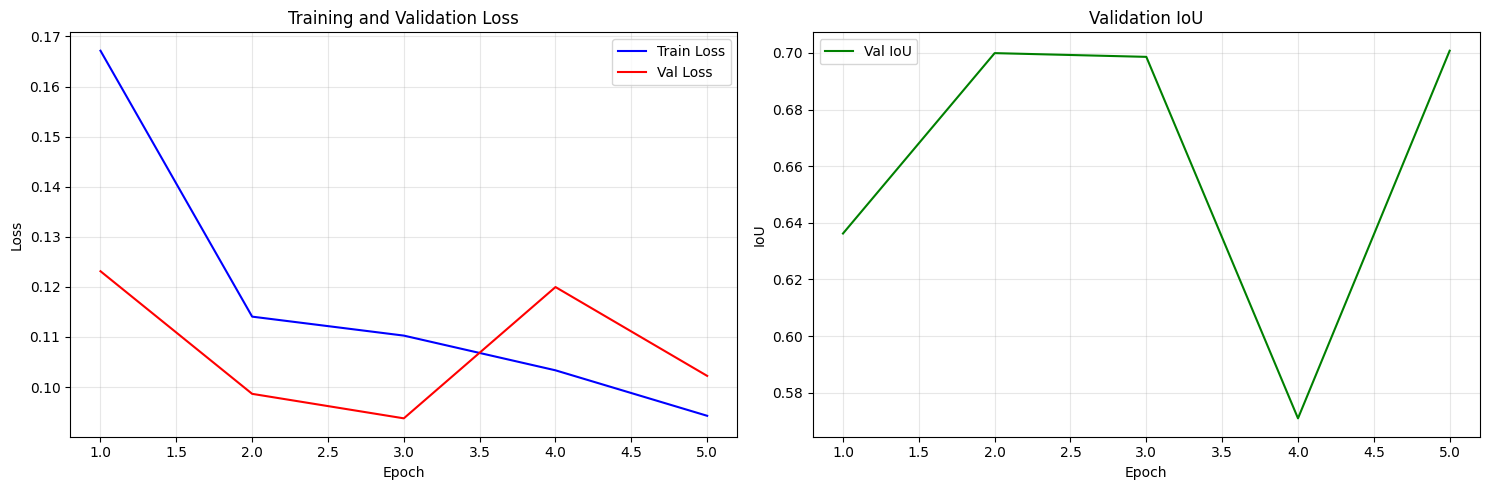

 TRAINING COMPLETED! 


In [14]:
print(" STARTING TRAINING ")
print("=" * 60)

# Create datasets
try:
    full_dataset = SegmentationDataset(config.IMAGES_PATH, config.MASKS_PATH)

    if len(full_dataset) == 0:
        print(" No data found! Check your file paths.")
    else:
        # Split dataset
        train_size = int(0.8 * len(full_dataset))
        val_size = len(full_dataset) - train_size
        train_dataset, val_dataset = torch.utils.data.random_split(
            full_dataset, [train_size, val_size]
        )

        # Create data loaders
        train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE,
                                shuffle=True, num_workers=2, pin_memory=True)
        val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)

        print(f" Training samples: {len(train_dataset)}")
        print(f" Validation samples: {len(val_dataset)}")

        # Initialize model
        model, criterion, optimizer = initialize_model()

        # Training history
        history = {
            'epoch': [],
            'train_loss': [],
            'val_loss': [],
            'val_iou': [],
            'learning_rate': []
        }

        best_iou = 0.0
        start_time = time.time()

        # TRAINING LOOP
        for epoch in range(config.NUM_EPOCHS):
            epoch_start = time.time()

            print(f"\n Epoch {epoch+1}/{config.NUM_EPOCHS}")
            print("-" * 25)

            # Train
            train_loss = train_epoch(model, train_loader, criterion, optimizer, config.DEVICE, epoch)

            # Validate -
            val_loss, val_iou = validate_epoch(model, val_loader, criterion, config.DEVICE, epoch)

            epoch_time = time.time() - epoch_start

            # Update history
            history['epoch'].append(epoch + 1)
            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['val_iou'].append(val_iou)
            history['learning_rate'].append(optimizer.param_groups[0]['lr'])

            # Print epoch summary
            print(f"Epoch {epoch+1} Summary:")
            print(f"   ├── Train Loss:    {train_loss:.4f}")
            print(f"   ├── Val Loss:      {val_loss:.4f}")
            print(f"   ├── Val IoU:       {val_iou:.4f}")
            print(f"   ├── Epoch Time:    {epoch_time:.2f}s")
            print(f"   └── Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")

            # Save best model
            if val_iou > best_iou:
                best_iou = val_iou
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'val_iou': val_iou,
                }, 'best_deeplabv3_model.pth')
                print(f" NEW BEST MODEL SAVED! IoU: {val_iou:.4f}")

        total_time = time.time() - start_time
        print(f"\n Training completed in {total_time:.2f} seconds")
        print(f" Best Validation IoU: {best_iou:.4f}")

        # Plot results
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 2, 1)
        plt.plot(history['epoch'], history['train_loss'], 'b-', label='Train Loss')
        plt.plot(history['epoch'], history['val_loss'], 'r-', label='Val Loss')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.plot(history['epoch'], history['val_iou'], 'g-', label='Val IoU')
        plt.title('Validation IoU')
        plt.xlabel('Epoch')
        plt.ylabel('IoU')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        print(" TRAINING COMPLETED! ")

except Exception as e:
    print(f" Error during training: {e}")
    import traceback
    traceback.print_exc()

In [16]:
#  Dice evaluation
def calculate_dice_coefficient(preds, targets):
    """Calculating  Dice Coefficient from predictions and targets."""

    preds = preds.cpu().numpy().flatten()
    targets = targets.cpu().numpy().flatten()

    intersection = np.sum(preds * targets)
    sum_of_areas = np.sum(preds) + np.sum(targets)

    if sum_of_areas == 0: # Both are empty
        return 1.0
    return (2. * intersection) / sum_of_areas

def quick_dice_evaluation(model, dataloader, device):
    model.eval()
    dice_scores = []

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs['out'], dim=1)
            dice = calculate_dice_coefficient(preds, masks)
            dice_scores.append(dice)

    mean_dice = np.mean(dice_scores)
    print(f" Quick Dice Evaluation: {mean_dice:.4f}")
    return mean_dice



quick_dice_evaluation(model, val_loader, config.DEVICE)


 Quick Dice Evaluation: 0.8222


np.float64(0.8222023707985303)

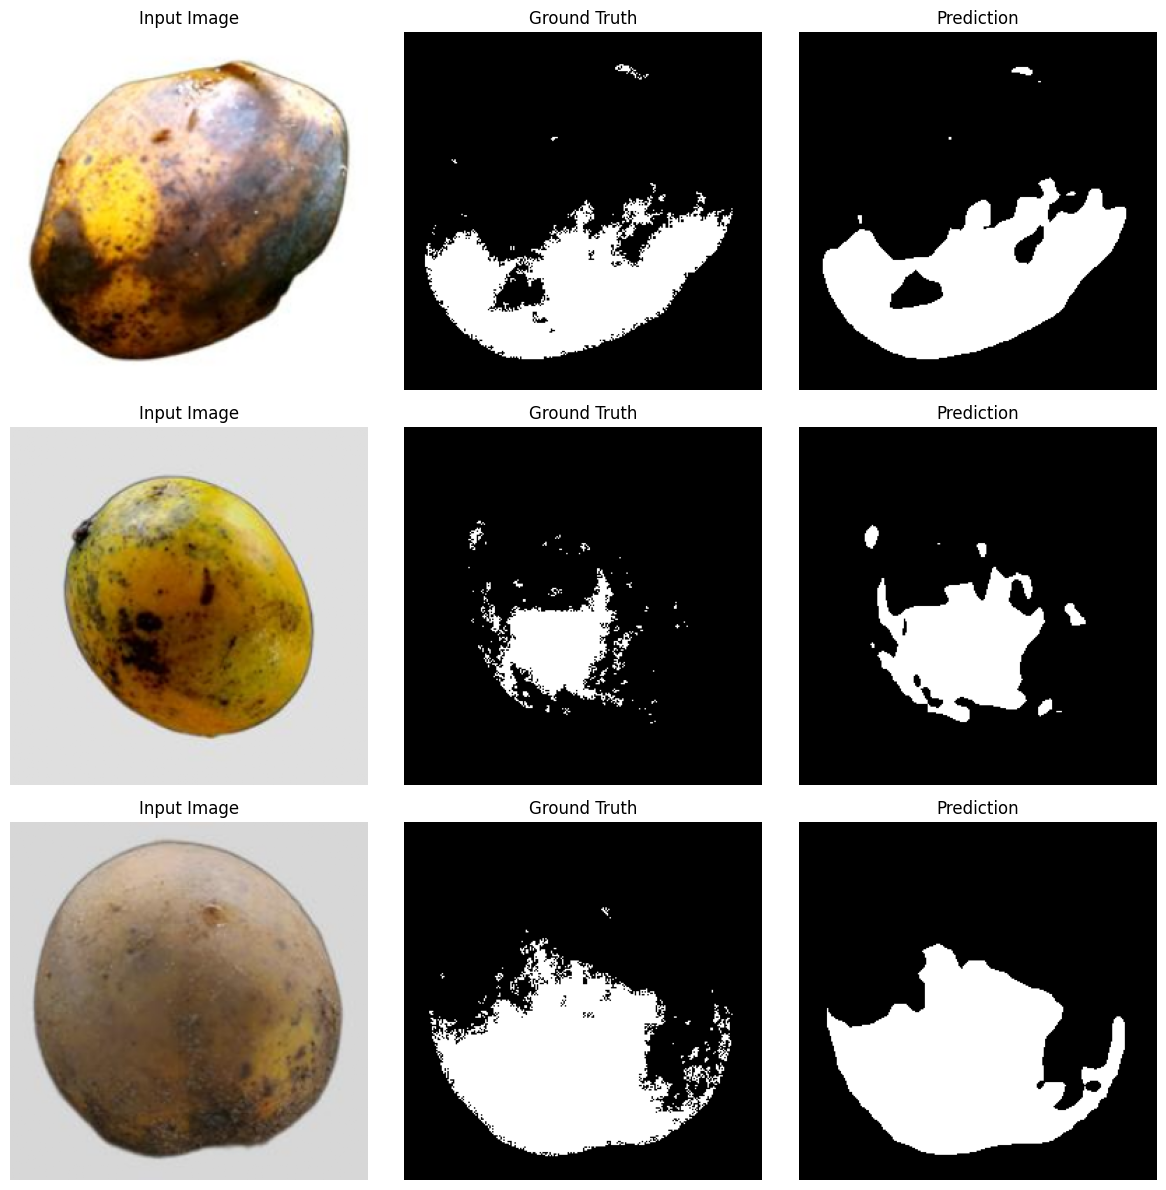

In [19]:
#  visualization function
def test_predictions(model, dataset, num_samples=3):
    """Test and visualize some predictions"""
    model.eval()

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    indices = np.random.choice(len(dataset), num_samples, replace=False)

    for i, idx in enumerate(indices):
        image, true_mask = dataset[idx]

        with torch.no_grad():
            input_tensor = image.unsqueeze(0).to(config.DEVICE)
            output = model(input_tensor)
            pred_mask = torch.argmax(output['out'], dim=1).squeeze().cpu().numpy()

        true_mask = true_mask.numpy()

        # Plot
        axes[i, 0].imshow(image.permute(1, 2, 0))
        axes[i, 0].set_title('Input Image')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(true_mask, cmap='gray')
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(pred_mask, cmap='gray')
        axes[i, 2].set_title('Prediction')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()


# Test predictions
try:
    test_predictions(model, val_dataset, num_samples=3)
except Exception as e:
    print(f" Prediction test failed, but training worked: {e}")

Analyzing CE Loss: 100%|██████████| 25/25 [03:19<00:00,  7.98s/it]



 Cross Entropy Loss Analysis:
 Mean Loss: 0.1022
 Std Loss:  0.2967
 Max Loss:  6.8985
Min Loss:  -0.0000
 Hard examples (top 10%): 655360 samples
Loss threshold for hard examples: 0.3028


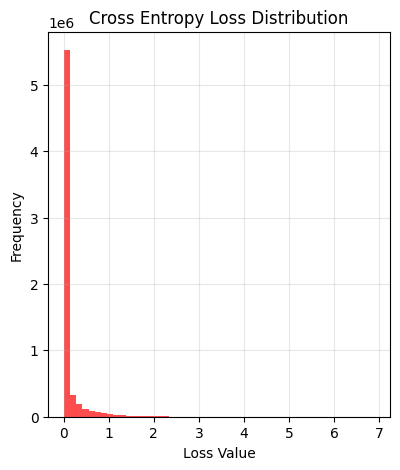

In [20]:
def analyze_cross_entropy_loss(model, dataloader, device):
    """Analyze how cross entropy loss behaves during training"""
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction='none')  # No reduction to see per-sample loss

    sample_losses = []
    predictions = []
    ground_truths = []

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Analyzing CE Loss"):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            # Calculate loss per sample (N, H, W)
            loss_per_sample = criterion(outputs['out'], masks)
            # Flatten the loss per pixel and add to the list
            sample_losses.extend(loss_per_sample.cpu().numpy().flatten())

            # Store predictions and ground truth for analysis
            preds = torch.argmax(outputs['out'], dim=1)
            predictions.extend(preds.cpu().numpy().flatten())
            ground_truths.extend(masks.cpu().numpy().flatten())

    # Convert to numpy arrays for analysis
    sample_losses = np.array(sample_losses)
    predictions = np.array(predictions)
    ground_truths = np.array(ground_truths)

    # Analysis
    print("\n Cross Entropy Loss Analysis:")
    print("=" * 50)
    print(f" Mean Loss: {np.mean(sample_losses):.4f}")
    print(f" Std Loss:  {np.std(sample_losses):.4f}")
    print(f" Max Loss:  {np.max(sample_losses):.4f}")
    print(f"Min Loss:  {np.min(sample_losses):.4f}")

    # Plot loss distribution
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.hist(sample_losses, bins=50, alpha=0.7, color='red')
    plt.title('Cross Entropy Loss Distribution')
    plt.xlabel('Loss Value')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)



    threshold = np.percentile(sample_losses, 90)
    hard_examples_idx = np.where(sample_losses > threshold)[0]

    print(f" Hard examples (top 10%): {len(hard_examples_idx)} samples")
    print(f"Loss threshold for hard examples: {threshold:.4f}")

    return sample_losses, hard_examples_idx

# Run the analysis
sample_losses, hard_examples = analyze_cross_entropy_loss(model, val_loader, config.DEVICE)

In [21]:
iou_scores = []
dice_coefficients = []
iou_losses = []
dice_losses = []

model.eval() # Set the model to evaluation mode

print("\n Calculating IoU, Dice Coefficient, IoU Loss, and Dice Loss for the validation set...")

with torch.no_grad(): # Disable gradient calculations
    for images, masks in tqdm(val_loader, desc="Evaluating Metrics"): # Iterate through the validation data loader
        images = images.to(config.DEVICE)
        masks = masks.to(config.DEVICE)

        outputs = model(images) # Make predictions
        pred_masks = torch.argmax(outputs['out'], dim=1) # Extract predicted masks

        # Calculate IoU
        iou = calculate_iou(pred_masks, masks)
        iou_scores.append(iou)
        iou_losses.append(1 - iou) # Calculate IoU Loss

        # Calculate Dice Coefficient
        dice = calculate_dice_coefficient(pred_masks, masks)
        dice_coefficients.append(dice)
        dice_losses.append(1 - dice) # Calculate Dice Loss

# Calculate mean metrics
mean_iou = np.mean(iou_scores)
mean_dice = np.mean(dice_coefficients)
mean_iou_loss = np.mean(iou_losses)
mean_dice_loss = np.mean(dice_losses)

print(f"\n --- Validation Metrics Summary ---")
print(f" Average IoU:              {mean_iou:.4f}")
print(f" Average Dice Coefficient: {mean_dice:.4f}")
print(f" Average IoU Loss:         {mean_iou_loss:.4f}")
print(f" Average Dice Loss:        {mean_dice_loss:.4f}")
print(f"----------------------------------")


 Calculating IoU, Dice Coefficient, IoU Loss, and Dice Loss for the validation set...


Evaluating Metrics:   0%|          | 0/25 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Evaluating Metrics: 100%|██████████| 25/25 [03:12<00:00,  7.68s/it]


 --- Validation Metrics Summary ---
 Average IoU:              0.7008
 Average Dice Coefficient: 0.8222
 Average IoU Loss:         0.2992
 Average Dice Loss:        0.1778
----------------------------------


In [28]:
def calculate_f1_score(preds, targets):
    """Calculate F1 Score from predictions and targets."""
    preds = preds.cpu().numpy().flatten()
    targets = targets.cpu().numpy().flatten()

    # True Positives, False Positives, False Negatives, True Negatives
    TP = np.sum((preds == 1) & (targets == 1))
    FP = np.sum((preds == 1) & (targets == 0))
    FN = np.sum((preds == 0) & (targets == 1))

    # Calculate Precision and Recall
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    # Calculate F1 Score
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    return f1_score

f1_scores = []

model.eval() # Ensure model is in evaluation mode

print("\n Calculating F1 Score for the validation set...")

with torch.no_grad():
    for images, masks in tqdm(val_loader, desc="Evaluating F1 Score"):
        images = images.to(config.DEVICE)
        masks = masks.to(config.DEVICE)

        outputs = model(images)
        pred_masks = torch.argmax(outputs['out'], dim=1)

        f1 = calculate_f1_score(pred_masks, masks)
        f1_scores.append(f1)

mean_f1 = np.mean(f1_scores)

print(f"\n --- Validation Metrics Summary (F1 Score) ---")
print(f" Average F1 Score: {mean_f1:.4f}")
print(f"---------------------------------------------")


 Calculating F1 Score for the validation set...


Evaluating F1 Score:   0%|          | 0/25 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Evaluating F1 Score: 100%|██████████| 25/25 [03:08<00:00,  7.56s/it]


 --- Validation Metrics Summary (F1 Score) ---
 Average F1 Score: 0.8222
---------------------------------------------


In [22]:
def calculate_precision_recall(preds, targets):
    """Calculate Precision and Recall"""
    preds = preds.cpu().numpy().flatten()
    targets = targets.cpu().numpy().flatten()

    # True Positives, False Positives, False Negatives
    TP = np.sum((preds == 1) & (targets == 1))
    FP = np.sum((preds == 1) & (targets == 0))
    FN = np.sum((preds == 0) & (targets == 1))

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    return precision, recall

precision_scores = []
recall_scores = []

model.eval() # Ensure model is in evaluation mode

print("\n Calculating Precision and Recall for the validation set...")

with torch.no_grad():
    for images, masks in tqdm(val_loader, desc="Evaluating Precision/Recall"):
        images = images.to(config.DEVICE)
        masks = masks.to(config.DEVICE)

        outputs = model(images)
        pred_masks = torch.argmax(outputs['out'], dim=1)

        precision, recall = calculate_precision_recall(pred_masks, masks)
        precision_scores.append(precision)
        recall_scores.append(recall)

mean_precision = np.mean(precision_scores)
mean_recall = np.mean(recall_scores)

print(f"\n --- Validation Metrics Summary (Precision/Recall) ---")
print(f" Average Precision: {mean_precision:.4f}")
print(f" Average Recall:    {mean_recall:.4f}")
print(f"-----------------------------------------------------")


 Calculating Precision and Recall for the validation set...


Evaluating Precision/Recall:   0%|          | 0/25 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Evaluating Precision/Recall: 100%|██████████| 25/25 [03:09<00:00,  7.57s/it]


 --- Validation Metrics Summary (Precision/Recall) ---
 Average Precision: 0.7543
 Average Recall:    0.9086
-----------------------------------------------------



 Calculating data for ROC curve...


  warnings.warn(warn_msg)



 --- ROC Curve and AUC Summary ---
 AUC (Area Under Curve): 0.9886
-----------------------------------


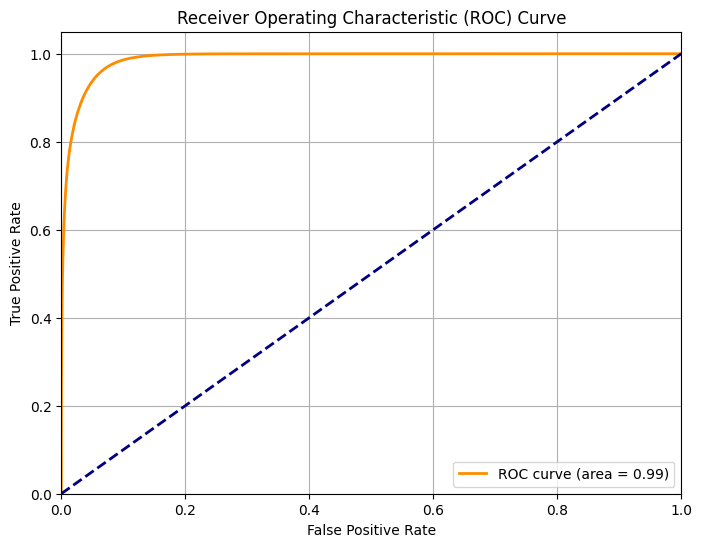

In [23]:
from sklearn.metrics import roc_curve, auc

all_preds = []
all_targets = []

model.eval() # Ensure model is in evaluation mode

print("\n Calculating data for ROC curve...")

with torch.no_grad():
    for images, masks in tqdm(val_loader, desc="Collecting ROC data"):
        images = images.to(config.DEVICE)
        masks = masks.to(config.DEVICE)

        outputs = model(images)
        # For binary classification (2 classes), outputs['out'] has shape (batch_size, 2, H, W)
        # We need the probability of the positive class (class 1)
        # Apply softmax to get probabilities from logits
        probabilities = torch.softmax(outputs['out'], dim=1)[:, 1, :, :]

        all_preds.extend(probabilities.cpu().numpy().flatten())
        all_targets.extend(masks.cpu().numpy().flatten())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(all_targets, all_preds)
roc_auc = auc(fpr, tpr)

print(f"\n --- ROC Curve and AUC Summary ---")
print(f" AUC (Area Under Curve): {roc_auc:.4f}")
print(f"-----------------------------------")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [27]:
import torch

# Define the path where the model will be saved
model_save_path = "current_deeplabv3_model.pth"

# Save the model's state dictionary
torch.save(model.state_dict(), model_save_path)

print(f"Model saved successfully to {model_save_path}")

Model saved successfully to current_deeplabv3_model.pth
